# Chapter 14: Statistics for Analysts

*Data Analytics with Python and Jupyter Notebook*

Run each cell in order with **Shift + Enter**. In this notebook we:

1. Describe data with the right summary statistics
2. Look at distributions and how samples behave
3. Build confidence intervals
4. Test an A/B experiment from the Bean There loyalty app (t-test, chi-square)
5. Separate correlation from causation

## 14.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 80)

## 14.2 Meet the data

Two new files: a loyalty-app **A/B test** (2,400 members, randomly given Promotion A or B, 2 to 15 March 2026) and a **customer survey** (600 respondents, March 2026).

In [2]:
ab = pd.read_csv("../data/ch14_promo_ab_test.csv")
ab.head()

,member_id,group,home_store,redeemed,visits,spend
0,10001,A,Downtown,0,9,59.80
1,10002,B,Downtown,1,11,53.37
2,10003,B,Downtown,0,8,62.76
3,10004,A,Downtown,1,9,57.39
4,10005,B,Downtown,1,6,35.88


In [3]:
ab.shape

(2400, 6)

In [4]:
survey = pd.read_csv("../data/ch14_survey.csv")
survey.head()

,respondent_id,store,age_group,visits_per_week,wait_minutes,satisfaction,would_recommend,favorite_product
0,1,Downtown,35-49,2,7,8,Yes,Latte
1,2,Downtown,18-24,1,3,7,No,Latte
2,3,Downtown,35-49,1,11,7,No,Latte
3,4,Downtown,25-34,1,9,5,No,Cappuccino
4,5,Riverside,35-49,0,6,8,Yes,Croissant


In [5]:
survey.shape

(600, 8)

## 14.3 Descriptive statistics

### Center: mean and median

In [6]:
ab["spend"].agg(["mean", "median"])

mean      22.350092
median    18.620000
Name: spend, dtype: float64

### Spread: standard deviation and percentiles

In [7]:
ab["spend"].std()

np.float64(19.326283385687237)

In [8]:
ab["spend"].quantile([0.10, 0.25, 0.50, 0.75, 0.90])

0.10     0.000
0.25     8.155
0.50    18.620
0.75    31.055
0.90    47.165
Name: spend, dtype: float64

In [9]:
q1, q3 = ab["spend"].quantile([0.25, 0.75])
print(f"IQR: {q3 - q1:.2f}")

IQR: 22.90


### Shape: skewness

In [10]:
ab["spend"].skew(), survey["satisfaction"].skew()

(np.float64(1.6509609239791303), np.float64(-0.254244175426255))

### Summaries by group

In [11]:
(survey
 .groupby("store")[["wait_minutes", "satisfaction"]]
 .agg(["mean", "median", "std"])
 .round(2))

wait_minutes              satisfaction             
                   mean median   std         mean median   std
store                                                         
Downtown           7.37    7.0  3.76         6.29    6.0  1.57
Riverside          3.29    3.0  1.78         7.55    8.0  1.28
University         5.67    5.0  2.59         6.59    7.0  1.33

### Categorical columns

In [12]:
survey["would_recommend"].value_counts(normalize=True)

would_recommend
Yes    0.615
No     0.385
Name: proportion, dtype: float64

## 14.4 Distributions

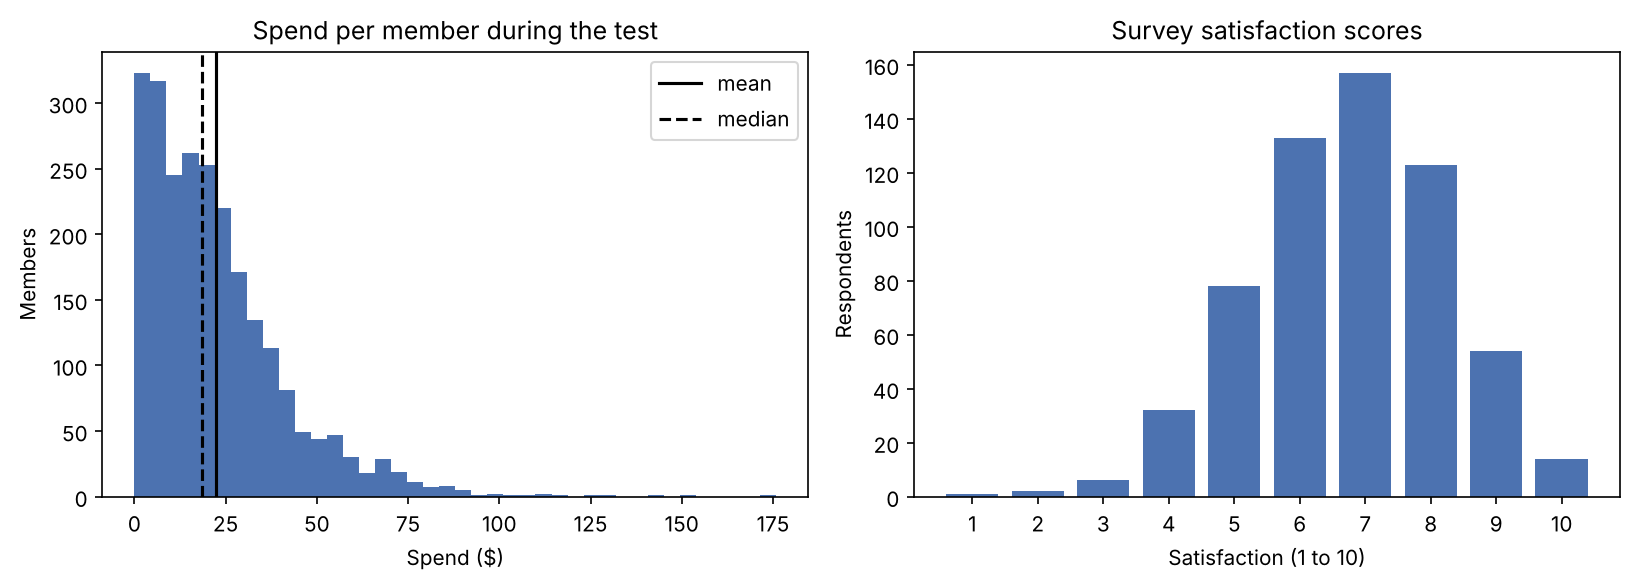

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(ab["spend"], bins=40, color="#4C72B0")
axes[0].axvline(ab["spend"].mean(), color="black", label="mean")
axes[0].axvline(ab["spend"].median(), color="black", linestyle="--",
                label="median")
axes[0].set_title("Spend per member during the test")
axes[0].set_xlabel("Spend ($)")
axes[0].set_ylabel("Members")
axes[0].legend()

counts = survey["satisfaction"].value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color="#4C72B0")
axes[1].set_title("Survey satisfaction scores")
axes[1].set_xlabel("Satisfaction (1 to 10)")
axes[1].set_ylabel("Respondents")
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

### The 68-95 rule

In [14]:
sat = survey["satisfaction"]
mean, sd = sat.mean(), sat.std()
within_1 = sat.between(mean - sd, mean + sd).mean()
within_2 = sat.between(mean - 2 * sd, mean + 2 * sd).mean()
print(f"mean {mean:.2f}, std {sd:.2f}")
print(f"within 1 std: {within_1:.1%}, within 2 std: {within_2:.1%}")

mean 6.75, std 1.50
within 1 std: 68.8%, within 2 std: 96.2%


## 14.5 Samples and populations

Treat the 2,400 test members as a whole **population** and see how much the mean of a random **sample** wobbles.

In [15]:
population = ab["spend"]
print(f"Population mean: {population.mean():.2f}")

rng = np.random.default_rng(14)
for i in range(5):
    sample = rng.choice(population, size=50, replace=False)
    print(f"Sample {i + 1} mean: {sample.mean():.2f}")

Population mean: 22.35
Sample 1 mean: 25.88
Sample 2 mean: 17.80
Sample 3 mean: 18.73
Sample 4 mean: 19.94
Sample 5 mean: 22.01


In [16]:
def sample_means(size, n_samples=2000):
    return np.array([
        rng.choice(population, size=size, replace=False).mean()
        for _ in range(n_samples)
    ])

means_50 = sample_means(50)
means_200 = sample_means(200)
print(f"Spread of means, n=50:  {means_50.std():.2f}")
print(f"Spread of means, n=200: {means_200.std():.2f}")

Spread of means, n=50:  2.74
Spread of means, n=200: 1.29


In [17]:
se_50 = population.std() / np.sqrt(50)
se_200 = population.std() / np.sqrt(200)
print(f"Formula, n=50:  {se_50:.2f}")
print(f"Formula, n=200: {se_200:.2f}")

Formula, n=50:  2.73
Formula, n=200: 1.37


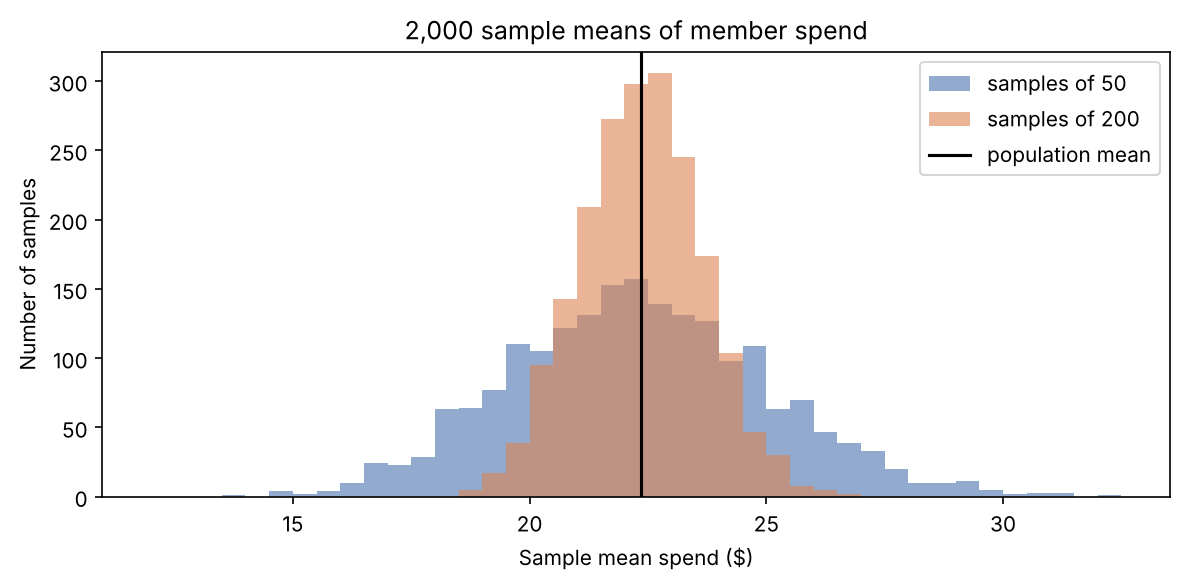

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(12, 33, 0.5)
ax.hist(means_50, bins=bins, color="#4C72B0", alpha=0.6,
        label="samples of 50")
ax.hist(means_200, bins=bins, color="#DD8452", alpha=0.6,
        label="samples of 200")
ax.axvline(population.mean(), color="black", label="population mean")
ax.set_title("2,000 sample means of member spend")
ax.set_xlabel("Sample mean spend ($)")
ax.set_ylabel("Number of samples")
ax.legend()
plt.tight_layout()
plt.show()

## 14.6 Confidence intervals

### A confidence interval for a mean

In [19]:
sat = survey["satisfaction"]
n = len(sat)
se = stats.sem(sat)
low, high = stats.t.interval(0.95, df=n - 1, loc=sat.mean(), scale=se)
print(f"Mean satisfaction: {sat.mean():.2f}")
print(f"Standard error:    {se:.3f}")
print(f"95% CI:            {low:.2f} to {high:.2f}")

Mean satisfaction: 6.75
Standard error:    0.061
95% CI:            6.63 to 6.87


### What "95%" means: a simulation

In [20]:
true_mean = population.mean()
hits = 0
for _ in range(1000):
    s = rng.choice(population, size=50, replace=False)
    lo, hi = stats.t.interval(0.95, df=49, loc=s.mean(),
                              scale=stats.sem(s))
    hits += lo <= true_mean <= hi
print(f"{hits} of 1000 intervals contain the true mean")

938 of 1000 intervals contain the true mean


### A confidence interval for a proportion

In [21]:
from statsmodels.stats.proportion import proportion_confint

yes = (survey["would_recommend"] == "Yes").sum()
n = len(survey)
low, high = proportion_confint(yes, n, alpha=0.05, method="wilson")
print(f"Would recommend: {yes / n:.1%} (95% CI {low:.1%} to {high:.1%})")

Would recommend: 61.5% (95% CI 57.5% to 65.3%)


In [22]:
rec = (survey
       .assign(yes=survey["would_recommend"] == "Yes")
       .groupby("store")["yes"]
       .agg(["sum", "count"]))
ci = proportion_confint(rec["sum"], rec["count"], method="wilson")
rec["rate"] = rec["sum"] / rec["count"]
rec["ci_low"], rec["ci_high"] = ci
rec.round(3)

,sum,count,rate,ci_low,ci_high
store,,,,,
Downtown,107,215,0.498,0.431,0.564
Riverside,129,164,0.787,0.718,0.842
University,133,221,0.602,0.536,0.664


## 14.7 Hypothesis tests and p-values

### The A/B test results

In [23]:
ab.groupby("group")[["redeemed", "visits", "spend"]].mean().round(3)

,redeemed,visits,spend
group,,,
A,0.263,3.611,22.217
B,0.312,3.625,22.483


### A p-value by shuffling

In [24]:
rates = ab.groupby("group")["redeemed"].mean()
observed = rates["B"] - rates["A"]
print(f"Observed difference: {observed:.3f}")

labels = ab["group"].to_numpy()
redeemed = ab["redeemed"].to_numpy()
diffs = []
for _ in range(10_000):
    shuffled = rng.permutation(labels)
    diff = (redeemed[shuffled == "B"].mean()
            - redeemed[shuffled == "A"].mean())
    diffs.append(diff)
diffs = np.array(diffs)
p_shuffle = (np.abs(diffs) >= abs(observed)).mean()
print(f"Shuffles at least as extreme: {p_shuffle:.4f}")

Observed difference: 0.049


Shuffles at least as extreme: 0.0078


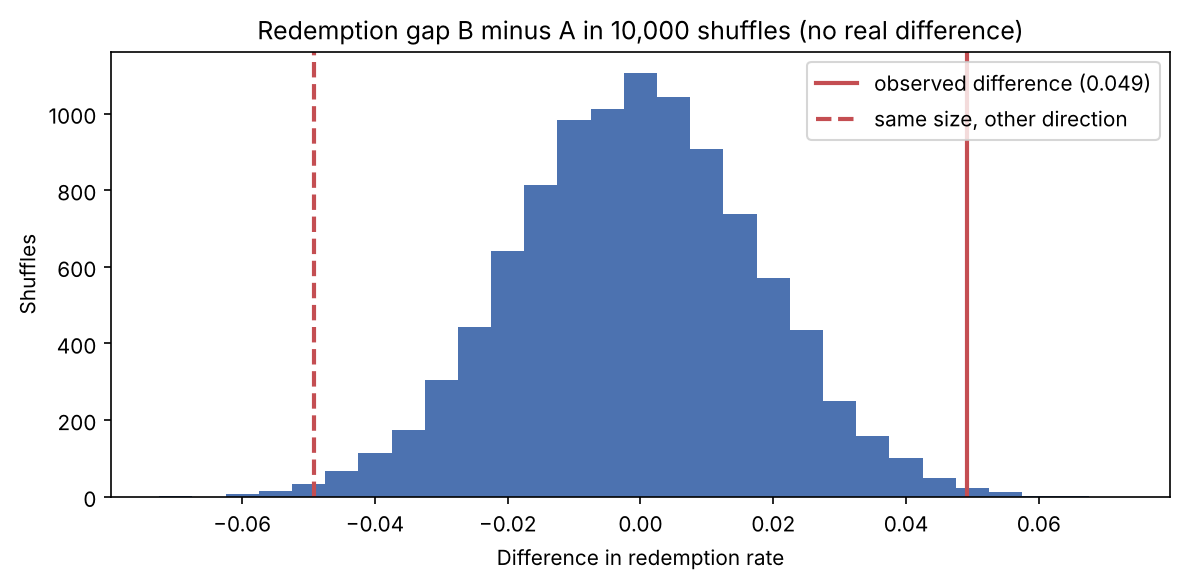

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(-0.0725, 0.073, 0.005)
ax.hist(diffs, bins=bins, color="#4C72B0")
ax.axvline(observed, color="#C44E52", linewidth=2,
           label=f"observed difference ({observed:.3f})")
ax.axvline(-observed, color="#C44E52", linewidth=2, linestyle="--",
           label="same size, other direction")
ax.set_title("Redemption gap B minus A in 10,000 shuffles "
             "(no real difference)")
ax.set_xlabel("Difference in redemption rate")
ax.set_ylabel("Shuffles")
ax.legend()
plt.tight_layout()
plt.show()

### Chi-square test for redemption

In [26]:
table = pd.crosstab(ab["group"], ab["redeemed"])
table

redeemed,0,1
group,,
A,884,316
B,825,375


In [27]:
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"chi-square = {chi2:.2f}, p-value = {p:.4f}")
print(expected)

chi-square = 6.84, p-value = 0.0089
[[854.5 345.5]
 [854.5 345.5]]


In [28]:
from statsmodels.stats.proportion import confint_proportions_2indep

counts = ab.groupby("group")["redeemed"].agg(["sum", "count"])
low, high = confint_proportions_2indep(
    counts.loc["B", "sum"], counts.loc["B", "count"],
    counts.loc["A", "sum"], counts.loc["A", "count"])
print(f"B minus A: {observed:.3f} (95% CI {low:.3f} to {high:.3f})")

B minus A: 0.049 (95% CI 0.013 to 0.085)


### t-test for spend

In [29]:
spend_a = ab.loc[ab["group"] == "A", "spend"]
spend_b = ab.loc[ab["group"] == "B", "spend"]
result = stats.ttest_ind(spend_b, spend_a, equal_var=False)
print(f"Mean A: {spend_a.mean():.2f}, mean B: {spend_b.mean():.2f}")
print(f"t = {result.statistic:.2f}, p-value = {result.pvalue:.3f}")

Mean A: 22.22, mean B: 22.48
t = 0.34, p-value = 0.735


In [30]:
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW

cm = CompareMeans(DescrStatsW(spend_b), DescrStatsW(spend_a))
low, high = cm.tconfint_diff(usevar="unequal")
print(f"B minus A: {spend_b.mean() - spend_a.mean():.2f} "
      f"(95% CI {low:.2f} to {high:.2f})")

B minus A: 0.27 (95% CI -1.28 to 1.81)


### Chi-square test on the survey

In [31]:
rec_table = pd.crosstab(survey["store"], survey["would_recommend"])
chi2, p, dof, expected = stats.chi2_contingency(rec_table)
print(rec_table)
print(f"chi-square = {chi2:.1f}, dof = {dof}, p-value = {p:.2g}")

would_recommend   No  Yes
store                    
Downtown         108  107
Riverside         35  129
University        88  133
chi-square = 33.1, dof = 2, p-value = 6.6e-08


### Why you should not run twenty tests and report the lucky one

In [32]:
false_alarms = 0
for _ in range(20):
    fake = rng.permutation(labels)
    a = ab.loc[fake == "A", "spend"]
    b = ab.loc[fake == "B", "spend"]
    if stats.ttest_ind(a, b, equal_var=False).pvalue < 0.05:
        false_alarms += 1
print(f"'Significant' results out of 20 fake tests: {false_alarms}")

'Significant' results out of 20 fake tests: 2


## 14.8 Correlation and causation

In [33]:
survey[["wait_minutes", "satisfaction", "visits_per_week"]].corr().round(2)

,wait_minutes,satisfaction,visits_per_week
wait_minutes,1.00,-0.57,0.01
satisfaction,-0.57,1.00,0.15
visits_per_week,0.01,0.15,1.00


In [34]:
r, p = stats.pearsonr(survey["wait_minutes"], survey["satisfaction"])
rho, p_s = stats.spearmanr(survey["wait_minutes"], survey["satisfaction"])
print(f"Pearson r = {r:.2f} (p = {p:.1g})")
print(f"Spearman rho = {rho:.2f} (p = {p_s:.1g})")

Pearson r = -0.57 (p = 4e-52)
Spearman rho = -0.53 (p = 2e-44)


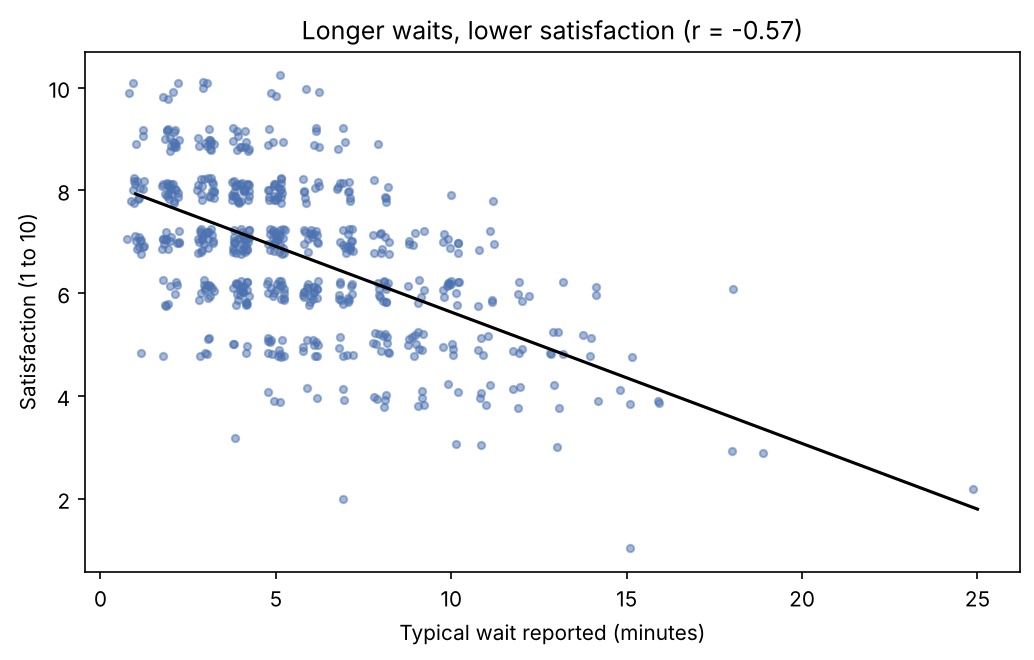

In [35]:
jitter = rng.uniform(-0.25, 0.25, size=(2, len(survey)))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(survey["wait_minutes"] + jitter[0],
           survey["satisfaction"] + jitter[1],
           s=12, alpha=0.5, color="#4C72B0")
slope, intercept = np.polyfit(survey["wait_minutes"],
                              survey["satisfaction"], 1)
xs = np.array([1, 25])
ax.plot(xs, intercept + slope * xs, color="black")
ax.set_title(f"Longer waits, lower satisfaction (r = {r:.2f})")
ax.set_xlabel("Typical wait reported (minutes)")
ax.set_ylabel("Satisfaction (1 to 10)")
plt.tight_layout()
plt.show()

### A correlation that is not what it seems

In [36]:
sales = pd.read_csv("../data/bean_there_sales.csv", parse_dates=["date"])
downtown = (sales[sales["store"] == "Downtown"]
            .pivot_table(index="date", columns="product",
                         values="quantity", aggfunc="sum"))
downtown["Latte"].corr(downtown["Croissant"]).round(2)

np.float64(0.34)

In [37]:
downtown["weekend"] = downtown.index.dayofweek >= 5
for is_weekend, days in downtown.groupby("weekend"):
    r = days["Latte"].corr(days["Croissant"])
    label = "Weekends" if is_weekend else "Weekdays"
    print(f"{label}: r = {r:.2f} ({len(days)} days)")

Weekdays: r = -0.01 (64 days)
Weekends: r = -0.05 (26 days)


In [38]:
downtown.groupby("weekend")[["Latte", "Croissant"]].mean().round(1)

product,Latte,Croissant
weekend,,
False,47.8,29.1
True,62.0,36.6


## Exercises

1. For each store in the survey, compute the median and the interquartile range (IQR) of `wait_minutes`. Which store has the most variable waits?
2. Build a 95% confidence interval for mean satisfaction at each store. Do the intervals overlap? *Hint:* loop over `survey.groupby("store")` and reuse `stats.t.interval`.
3. **Check the randomization.** Use a chi-square test to see whether the A and B groups have a similar mix of home stores. What p-value would you hope to see?
4. Did Promotion B change the number of **visits**? Run a Welch t-test and give a 95% CI for the difference.
5. Use `stats.f_oneway` (one-way ANOVA) to test whether mean satisfaction differs between the three stores.
6. In `bean_there_sales.csv`, total revenue per day across all stores, then test whether weekend days earn more than weekdays. Report the difference with a 95% CI.
7. **Think about it:** survey respondents who visit more often are slightly more satisfied. Marketing wants a punch card to raise visits "so that satisfaction goes up". Give two other explanations for the correlation and describe how you would test the idea properly.